# Puzzle block signatures

Explore **non-isomorphic puzzle classes**, counted once each. Use the **v2/.venv** kernel and run the cells in order. No enumeration or graph search is needed: the saved database contains the complete results.

The default cohort is `"all"`. Change `COHORT` below to choose:

- `"all"`: **7,073** classes, retaining mirror pairs and dead ends (**default**).
- `"filtered"`: **4,857** classes, identifying mirrors and excluding permanently frozen or one-axis puzzles.
- `"mirror"`: 4,860 classes, merging mirrors and retaining dead ends.
- `"mobile"`: 7,070 classes, removing dead ends and retaining mirror pairs.

All cohorts exclude invisible core bonds and **include every implicit adjacent bond**. Signatures describe these effective blocks, rather than a particular glue recipe that may contain further implicit connections.


In [15]:
import csv
import html
import sys
from pathlib import Path

import bce_v2 as c
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, display

%matplotlib inline

COHORT = "all"  # Change to "filtered" to identify mirrors and exclude dead ends.
root = next(path for path in (Path.cwd(), *Path.cwd().parents)
            if (path / "v2/enumeration-results/2026-10-07-shell-signatures.sqlite3").is_file())
results = root / "v2/enumeration-results"
database = results / "2026-10-07-shell-signatures.sqlite3"
if "atlas" in globals():
    atlas.close()
atlas = c.PuzzleAtlas(database, cohort=COHORT)
print("Kernel:", sys.executable)
print(f"Cohort: {atlas.cohort}; {len(atlas):,} puzzle classes")


Kernel: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/.venv/bin/python
Cohort: all; 7,073 puzzle classes


In [16]:
def table(rows, columns=None, *, max_height=600):
    """Display every row in a scrollable table without requiring pandas."""
    rows = list(rows)
    if not rows:
        display(Markdown("No matches."))
        return
    columns = columns or list(rows[0])
    heading = "".join(f"<th>{html.escape(str(column))}</th>" for column in columns)
    body = "".join("<tr>" + "".join(
        f"<td>{html.escape(str(row[column]))}</td>" for column in columns) + "</tr>"
        for row in rows)
    display(HTML(f'<div style="max-height:{max_height}px;overflow:auto">'
                 f'<table><thead><tr>{heading}</tr></thead><tbody>{body}</tbody></table></div>'
                 f'<p>{len(rows):,} rows shown; scroll to see all rows.</p>'))


def gallery(rows, *, limit=6):
    rows = list(rows)[:limit]
    if not rows:
        return
    visible_faces = ({cell for cell in range(27) if cell // 9 == 0},
                     {cell for cell in range(27) if (cell // 3) % 3 == 2},
                     {cell for cell in range(27) if cell % 3 == 2})

    def visible_bonds(shape):
        return sum(shape[cell] == shape[cell + stride]
                   for face in visible_faces for cell in face for stride in (1, 3, 9)
                   if (cell // stride) % 3 < 2 and cell + stride in face)

    shapes = [max((atlas.shape(row["id"]).rotated(rotation) for rotation in range(24)),
                  key=visible_bonds) for row in rows]
    figure = c.draw_cubes(shapes, ncol=3, size=3)
    figure.set_size_inches(9 if len(rows) >= 3 else 3 * len(rows), 3.5 * ((len(rows) + 2) // 3))
    figure.subplots_adjust(wspace=0.08, hspace=0.35, top=0.9, bottom=0.02)
    for axis, row in zip(figure.axes, rows):
        axis.set_title(row["id"] + "\n" + row["signature"], fontsize=9)
    plt.show()


## What a signature means

A block type includes both its sorted dimensions and its center/core placement. `221` and `221Core` share a 2×2×1 box, but `221` is on an outer face and `221Core` passes through the core position. In the default shell model the core is omitted: `221Core` has three physical cubies, including two centers. Likewise, `321Core` has five physical cubies and three centers, while outer `321` has six cubies and one center.

`211` splits into **Clock** (one face center) and **Pair** (no face center). A center-containing `311` is **BigClock**; `311` means the bar with no center. The middle-layer variant of `331` is **331Core**. The optional core-enabled model also has **211Core** and **311Core**; these cannot appear in the default shell atlas. `222`, `322` (BigBlock), `332`, and `333` each have one center/core placement pattern and retain their numeric names.

All singleton cubies remain **111**, including free face centers. They are omitted from labels; the unbandaged puzzle is labeled `111 only`. Now that larger-block variants are distinguished, a signature determines the number of remaining physical singletons. The ghost core is not counted.

Types appear largest first by bounding-box volume, with dimensions breaking ties. A count of one has no prefix: `2x221 Clock 2xPair`.

Rigid turns, whole-cube rotations, and mirrors preserve these types. Signatures are therefore class properties, though many classes can share one. Galleries show a whole-cube rotation chosen to expose fused faces; captions retain the original stable puzzle IDs.


In [17]:
catalogue = []
for block in c.BLOCK_TYPES:
    sizes = atlas.query("SELECT DISTINCT cubies FROM blocks WHERE block_type = ? ORDER BY cubies",
                        (block.code,))
    catalogue.append({"type": block.code, "dimensions": "x".join(map(str, block.dimensions)),
                      "face centers": block.centers if block.centers is not None else "varies",
                      "box includes core": block.core_position if block.core_position is not None else "varies",
                      "shell cubies observed": ", ".join(str(row["cubies"]) for row in sizes) or "core-enabled only",
                      "description": block.description})
table(catalogue)
print("Formatting example:", c.format_signature({"Pair": 2, "221": 2, "Clock": 1}))


type,dimensions,face centers,box includes core,shell cubies observed,description
333,3x3x3,6,True,26,The whole cube shell
332,3x3x2,5,True,17,Two full layers fused together
322,3x2x2,4,True,11,A 3×2×2 bounding box
331,3x3x1,1,False,9,An outer layer with one face center
331Core,3x3x1,4,True,8,A middle layer with four face centers
222,2x2x2,3,True,7,A 2×2×2 bounding box
321,3x2x1,1,False,6,An outer 3×2×1 rectangle
321Core,3x2x1,3,True,5,A middle 3×2×1 box with three face centers
221,2x2x1,1,False,4,An outer 2×2×1 rectangle
221Core,2x2x1,2,True,3,A middle 2×2×1 box with two face centers


Formatting example: 2x221 Clock 2xPair


## Compare the atlases

Mirror merging changes the number of puzzles for a signature, but never creates a new signature: mirror partners have the same inventories. The agreed dead-end filter removes three signatures, corresponding to the fused shell and the two slab puzzles. The fully fused `333`, `332`, `331`, and `331Core` types do not occur in the filtered cohort.


In [18]:
comparison = []
for cohort in c.PuzzleAtlas.COHORTS:
    with c.PuzzleAtlas(database, cohort=cohort) as other:
        maximum, maximal = other.maximum("211", only=("211",))
        comparison.append({"cohort": cohort, "puzzles": len(other),
                           "signatures": len(other.signature_counts()),
                           "contain 222": len(other.containing("222")),
                           "maximum 211-only blocks": maximum,
                           "puzzles reaching maximum": len(maximal)})
table(comparison)


cohort,puzzles,signatures,contain 222,maximum 211-only blocks,puzzles reaching maximum
all,7073,1735,339,12,2
mirror,4860,1735,238,12,1
mobile,7070,1732,339,12,2
filtered,4857,1732,238,12,1


## How many puzzles contain a 222 block?

`containing` counts classes with **at least one** matching block, rather than counting block occurrences. Change `BLOCK` and `AT_LEAST` below to ask other questions, including `"221Core"`, `"321Core"`, and `"BigClock"`.

Names match exact variants: `"221"` excludes `221Core`, and `"311"` excludes BigClock. Numeric `"211"` is a family query combining Clock and Pair; use their individual names to count them separately.


339 of 7,073 classes contain at least 1 222 block(s).


id,signature,singletons,fixed_frame_vertices,ever_axes
000450010c000b,222,19,1,3
000450010c000f,222 Pair,17,18,3
000450010c002b,222 Clock,17,4,3
000450010c002f,222 Clock Pair,15,62,3
000450010c004f,222 2xPair,15,129,3
000450010c006f,222 Clock 2xPair,13,370,3
000450010c00ab,222 2xClock,15,15,3
000450010c00af,222 2xClock Pair,13,196,3
000450010c00ef,222 2xClock 2xPair,11,970,3
000450010c014f,222 3xPair,13,450,3


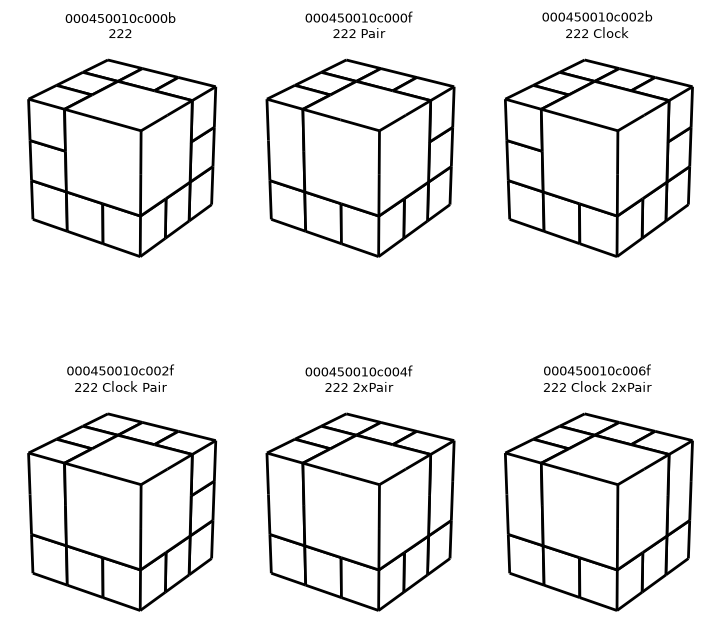

In [19]:
BLOCK = "222"
AT_LEAST = 1
matching = atlas.containing(BLOCK, at_least=AT_LEAST)
print(f"{len(matching):,} of {len(atlas):,} classes contain at least {AT_LEAST} {BLOCK} block(s).")
table(matching[:12], ["id", "signature", "singletons", "fixed_frame_vertices", "ever_axes"])
gallery(matching)


## How common is each block type?

This distinguishes puzzle counts from total block occurrences. `max_per_puzzle` gives the largest multiplicity of that type in the selected cohort, allowing other block types as well.

**Why does `332` appear in just one puzzle in `"all"`?** A `332` block leaves only the remaining face turnable. Its nine cubies always move together, so implicit-bond closure fuses them into a `331` block, regardless of their explicit bandaging. All 322 rectangular partitions of that face close to the same `332 331` class. It is retained in `"all"` and removed as permanently one-axis in `"filtered"`. Thus these counts describe effective blocks after closure, rather than all explicit glue recipes.


In [20]:
prevalence = atlas.query(f"""
    WITH per_puzzle AS (
        SELECT b.block_type, b.puzzle_id, COUNT(*) AS blocks
        FROM blocks b JOIN puzzles_{atlas.cohort} p ON p.id = b.puzzle_id
        GROUP BY b.block_type, b.puzzle_id
    )
    SELECT t.code AS type, COUNT(*) AS puzzles_containing,
           SUM(q.blocks) AS total_blocks, MAX(q.blocks) AS max_per_puzzle
    FROM per_puzzle q JOIN block_types t ON t.code = q.block_type
    GROUP BY t.code ORDER BY t.display_order
""")
table(prevalence)


type,puzzles_containing,total_blocks,max_per_puzzle
333,1,1,1
332,1,1,1
322,101,101,1
331,2,3,2
331Core,1,1,1
222,339,339,1
321,1469,1521,3
321Core,1376,1376,1
221,3812,5264,4
221Core,2255,2255,1


## Maximum number of 211 blocks, with only 111 remaining

This asks for the **global maximum number of dominoes** among classes with no larger blocks. Both Clock and Pair count as `211`. It does not ask for an arrangement to which no further domino can be added.

Twelve is also a geometric upper bound: the shell has twelve edge cubies, and every adjacent 211 pairs one edge with a corner or a center. There are fourteen corners/centers in total, leaving two singletons when all twelve edges are paired.


Maximum: 12 dominoes; 2 puzzle class(es).


id,signature,singletons,block_count,mirror_id
0000100071df00,5xClock 7xPair,2,12,0000100073de00
0000100073de00,5xClock 7xPair,2,12,0000100071df00


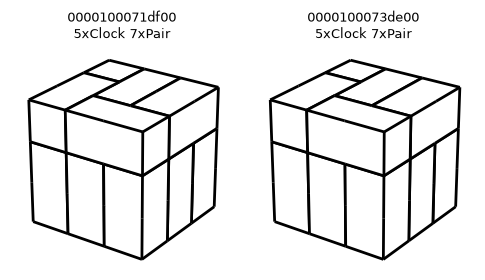

In [21]:
maximum, maximal_domino_puzzles = atlas.maximum("211", only=("211",))
print(f"Maximum: {maximum} dominoes; {len(maximal_domino_puzzles)} puzzle class(es).")
table(maximal_domino_puzzles, ["id", "signature", "singletons", "block_count", "mirror_id"])
gallery(maximal_domino_puzzles)


The two maximum-domino classes in the full atlas are a mirror pair. Their signature is `5xClock 7xPair`, with two singleton cubies. Additional restrictions are easy to express:


In [22]:
restrictions = []
for block, allowed in (("Pair", ("Pair",)), ("Clock", ("Clock",)), ("Pair", ("211",))):
    maximum, matches = atlas.maximum(block, only=allowed)
    restrictions.append({"maximize": block, "allowed nonsingletons": ", ".join(allowed),
                         "maximum": maximum, "puzzles": len(matches)})
table(restrictions)


maximize,allowed nonsingletons,maximum,puzzles
Pair,Pair,7,1
Clock,Clock,5,1
Pair,211,7,10


## Exact signatures and combinations

The following query asks for exactly two 221 blocks, one Clock, and two Pairs, with the remaining physical cubies singleton. Change the dictionary to explore another inventory. Different geometries may have the same signature.


2x221 Clock 2xPair: 3 classes


id,signature,singletons,fixed_frame_vertices,ever_axes
0000000514016f,2x221 Clock 2xPair,12,2356,3
000050041c01e4,2x221 Clock 2xPair,12,1834,3
000050041c1164,2x221 Clock 2xPair,12,2074,3


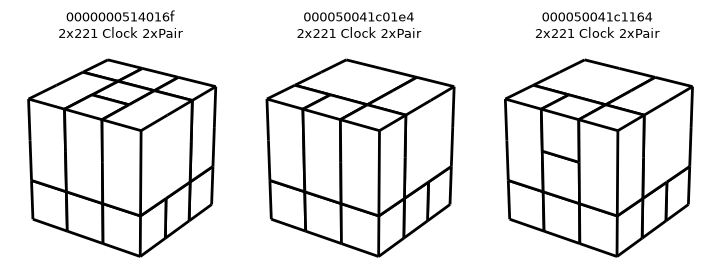

In [23]:
wanted = {"221": 2, "Clock": 1, "Pair": 2}
wanted_text = c.format_signature(wanted)
exact = atlas.select(signature=wanted_text)
print(f"{wanted_text}: {len(exact):,} classes")
table(exact[:12], ["id", "signature", "singletons", "fixed_frame_vertices", "ever_axes"])
gallery(exact)


In [24]:
# Combine minimum counts with an allowed inventory.
combined = atlas.select(contains={"Clock": 2, "Pair": 2}, only=("211",))
print(f"Domino-only classes with at least two Clocks and two Pairs: {len(combined):,}")
table(combined[:12], ["id", "signature", "singletons"])


Domino-only classes with at least two Clocks and two Pairs: 43


id,signature,singletons
0000000000000f,2xClock 2xPair,18
0000000000002d,2xClock 2xPair,18
0000000000002f,3xClock 2xPair,16
0000000000004f,2xClock 3xPair,16
0000000000006d,2xClock 3xPair,16
0000000000006f,3xClock 3xPair,14
000000000000af,4xClock 2xPair,14
000000000000ef,4xClock 3xPair,12
0000000000014f,2xClock 4xPair,14
0000000000016d,2xClock 4xPair,14


## Every signature and its number of puzzle classes

**Every row** for the selected cohort is shown below, sorted by puzzle count. Each signature lists blocks largest first. Scroll through the table or search this notebook for a type or signature.

The saved `2026-10-07-shell-signatures.csv` lists all **1,735** position-aware signatures with counts for all four cohorts; **1,732** occur in the filtered atlas. The CSV opens in a spreadsheet without running this notebook. Counts in each cohort sum to its complete puzzle total.


In [25]:
signatures = atlas.signature_counts()
assert sum(row["puzzles"] for row in signatures) == len(atlas)
assert all(row["singletons_min"] == row["singletons_max"] for row in signatures)
print(f"{len(signatures):,} distinct signatures covering {len(atlas):,} classes.")
table(signatures, ["signature", "puzzles", "singletons"], max_height=750)
print("Full four-cohort CSV:", results / "2026-10-07-shell-signatures.csv")


1,735 distinct signatures covering 7,073 classes.


signature,puzzles,singletons
2x221 311 2xClock 3xPair,40,5
221 221Core 311 2xClock 4xPair,36,4
221 221Core 311 BigClock Clock 3xPair,34,5
221Core 2x311 2xClock 2xPair,29,9
2x221 221Core 311 Clock 3xPair,29,4
221 221Core 311 3xClock 4xPair,28,2
221 221Core 311 BigClock 2xClock 3xPair,28,3
321 221 221Core 2xClock 3xPair,28,3
321 221 221Core Clock 3xPair,28,5
2x311 BigClock 2xClock 2xPair,27,9


Full four-cohort CSV: /home/ladislav/prj/nonvl/bandaged-cube-explorer/v2/enumeration-results/2026-10-07-shell-signatures.csv


## Which signatures occur in the most puzzles?

A signature forgets how the blocks are arranged. This table compares the number of classes and the range of shape-component sizes for the most frequent inventories. `fixed_frame_vertices` describes bandage shapes, not the much larger colored-state graph.


In [26]:
view = "puzzles_" + atlas.cohort  # cohort is validated by PuzzleAtlas
popular = atlas.query(f"""
    SELECT signature, COUNT(*) AS puzzles,
           MIN(fixed_frame_vertices) AS smallest_shape_component,
           MAX(fixed_frame_vertices) AS largest_shape_component
    FROM {view}
    GROUP BY signature
    ORDER BY puzzles DESC, signature LIMIT 15
""")
table(popular)


signature,puzzles,smallest_shape_component,largest_shape_component
2x221 311 2xClock 3xPair,40,46,740
221 221Core 311 2xClock 4xPair,36,52,773
221 221Core 311 BigClock Clock 3xPair,34,51,563
221Core 2x311 2xClock 2xPair,29,82,576
2x221 221Core 311 Clock 3xPair,29,28,242
221 221Core 311 3xClock 4xPair,28,58,354
221 221Core 311 BigClock 2xClock 3xPair,28,60,360
321 221 221Core 2xClock 3xPair,28,28,186
321 221 221Core Clock 3xPair,28,23,274
2x311 BigClock 2xClock 2xPair,27,45,646


## Compare placement variants directly

This query shows all placement variants of a 221, including their corner/edge/center counts. Each row counts **puzzles containing** that type, rather than counting occurrences. Change `DIMENSIONS` to `"321"` or `"311"` to inspect 321Core or BigClock as well. The `block_inventory` view exposes dimensions for queries that deliberately combine the variants.


In [27]:
DIMENSIONS = "221"
refined = atlas.query(f"""
    SELECT b.block_type, b.cubies, b.corners, b.edges, b.centers,
           b.cores, b.core_hole, COUNT(DISTINCT b.puzzle_id) AS puzzles
    FROM block_inventory b JOIN {view} p ON p.id = b.puzzle_id
    WHERE b.dimensions = ?
    GROUP BY b.block_type, b.cubies, b.corners, b.edges, b.centers, b.cores, b.core_hole
    ORDER BY b.cubies DESC
""", (DIMENSIONS,))
table(refined)


block_type,cubies,corners,edges,centers,cores,core_hole,puzzles
221,4,1,2,1,0,0,3812
221Core,3,0,1,2,0,1,2255


The named types now fully specify each nonsingleton block's cubie composition. Adding singleton counts or the detailed cubie-kind inventory therefore gives the same number of signatures:


In [28]:
refined_totals = atlas.query(f"""
    SELECT
        (SELECT COUNT(DISTINCT signature) FROM {view}) AS named_block_signatures,
        (SELECT COUNT(*) FROM (SELECT 1 FROM {view} GROUP BY signature, singletons))
            AS including_singleton_count,
        (SELECT COUNT(DISTINCT detailed_signature) FROM {view}) AS including_cubie_kinds
""")
table(refined_totals)
assert len(set(refined_totals[0].values())) == 1


named_block_signatures,including_singleton_count,including_cubie_kinds
1735,1735,1735


## Questions to explore next

- **Placement versus inventory:** which signature has the most distinct puzzles, and can their arrangements be classified into useful geometric families?
- **Mobility within a signature:** why can identical block counts give very different reachable shape counts? Which inventories allow all three axes, and which require a long unlocking sequence?
- **Chirality:** which signatures contain only self-mirror puzzles, only chiral pairs, or both? Can a small arrangement explain the difference?
- **Placement variants:** how differently do 221 and 221Core, 321 and 321Core, or 311 and BigClock affect mobility and achievable inventories?
- **Minimal bandaging:** how many effective blocks or bonds are needed to force a particular mobility restriction? Compare explicit glue recipes with their implicit closure.
- **Packing and feasibility:** can impossible signatures be ruled out from cubie counts or adjacency constraints before classifying their arrangements?
- **Colored complexity:** do puzzles with the same block signature have very different colored-state group sizes or solving difficulty? This needs further analysis beyond shape-component size.

The coarse signature is intentionally an inventory, not a complete isomorphism invariant. All queries here continue to count full puzzle classes from the certified atlas.
